In [19]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import random

In [20]:
def evaluate_policy(env, policy, episodes, max_steps, gamma=0.99):
    Q_values = np.zeros((env.observation_space.n, env.action_space.n, 2))
    
    for episode in range(episodes):
        state = random.randint(0, env.observation_space.n - 1)
        action = random.randint(0, env.action_space.n - 1)
        
        env.reset()
        env.unwrapped.s = state 
        
        done = False
        trajectory = []
        
        for i in range(max_steps):
            next_state, reward, done, _, _ = env.step(action)
            trajectory.append((state, action, reward))
            if done:
                break
            state = next_state
            action = policy[state]
            
        G = 0
        episode_updates = {}
        
        for state, action, reward in reversed(trajectory):
            G = reward + gamma * G
            episode_updates[(state, action)] = G
            
        for (state, action), final_G in episode_updates.items():
            Q_values[state, action, 0] += final_G
            Q_values[state, action, 1] += 1
            
    # ret = np.zeros((env.observation_space.n, env.action_space.n))
    # for i in range(env.observation_space.n):
    #     for j in range(env.action_space.n):
    #         if(Q_values[i][j][1] != 0):
    #             ret[i][j] = Q_values[i][j][0]/Q_values[i][j][1]
    #         else:
    #             ret[i][j] = 0;
    # return ret
    return Q_values[:, :, 0] / np.maximum(Q_values[:, :, 1], 1e-8)

In [21]:
def improve_policy(env, Q_values, gamma=0.99):
    new_policy = np.argmax(Q_values, axis=1)
    return new_policy

In [22]:
def policy_iteration(env, gamma=0.99, theta=1e-8):
    n_states = env.observation_space.n
    policy = np.zeros(n_states, dtype=int) 
    
    while True:
        V = evaluate_policy(env, policy, 100, 50, gamma) 
        new_policy = improve_policy(env, V, gamma)
        if np.array_equal(policy, new_policy):
            break
            
        policy = new_policy
        
    return policy, V

In [23]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}
	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)
			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]
			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")
	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

In [24]:
def run_and_plot_mc_policy_iteration(env, max_iterations=2000, gamma=0.99):
    import matplotlib.pyplot as plt
    
    # 1. Helper function to isolate evaluation metrics from training data
    def test_current_policy(env, policy, test_episodes=100, max_steps=100):
        total_rewards = 0
        total_lengths = 0
        for _ in range(test_episodes):
            state, _ = env.reset()
            length = 0
            while True:
                action = policy[state]
                state, reward, done, truncated, _ = env.step(action)
                length += 1
                if done or truncated:
                    total_rewards += reward
                    break
            total_lengths += length
        return total_rewards / test_episodes, total_lengths / test_episodes

    # 2. Initialization
    n_states = env.observation_space.n
    policy = np.zeros(n_states, dtype=int)
    
    rewards_history = []
    lengths_history = []
    
    # Track initial baseline performance
    r_avg, l_avg = test_current_policy(env, policy)
    rewards_history.append(r_avg)
    lengths_history.append(l_avg)
    print(f"Iteration 0: Baseline Avg Reward = {r_avg:.2f}, Avg Length = {l_avg:.2f}")
    
    # 3. Main Policy Iteration Loop
    for idx in range(1, max_iterations + 1):
        # Your custom MC evaluation function
        Q = evaluate_policy(env, policy, episodes=2000, max_steps=100, gamma=gamma)
        
        # Your custom improve policy function 
        new_policy = improve_policy(env, Q)
        
        # Test performance of the newly generated policy
        r_avg, l_avg = test_current_policy(env, new_policy)
        rewards_history.append(r_avg)
        lengths_history.append(l_avg)
        print(f"Iteration {idx}: Updated Avg Reward = {r_avg:.2f}, Avg Length = {l_avg:.2f}")
        
        if np.array_equal(policy, new_policy):
            print(f"--> Success: Policy stabilized at iteration {idx}!")
            break
            
        policy = new_policy

    # 4. Generate Subplots
    iterations = list(range(len(rewards_history)))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left Plot: Average Rewards
    ax1.plot(iterations, rewards_history, marker='o', color='tab:blue', linewidth=2)
    ax1.set_title("Average Reward vs. Iterations")
    ax1.set_xlabel("Policy Iteration Index")
    ax1.set_ylabel("Mean Reward")
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.set_xticks(iterations)
    
    # Right Plot: Average Episode Lengths
    ax2.plot(iterations, lengths_history, marker='s', color='tab:orange', linewidth=2)
    ax2.set_title("Average Episode Length vs. Iterations")
    ax2.set_xlabel("Policy Iteration Index")
    ax2.set_ylabel("Mean Step Steps")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.set_xticks(iterations)
    
    plt.tight_layout()
    plt.show()

In [25]:
env = gym.make('FrozenLake-v1', desc=None, map_name="8x8", is_slippery=False)

In [26]:
optimal_policy, optimal_values = policy_iteration(env.unwrapped)

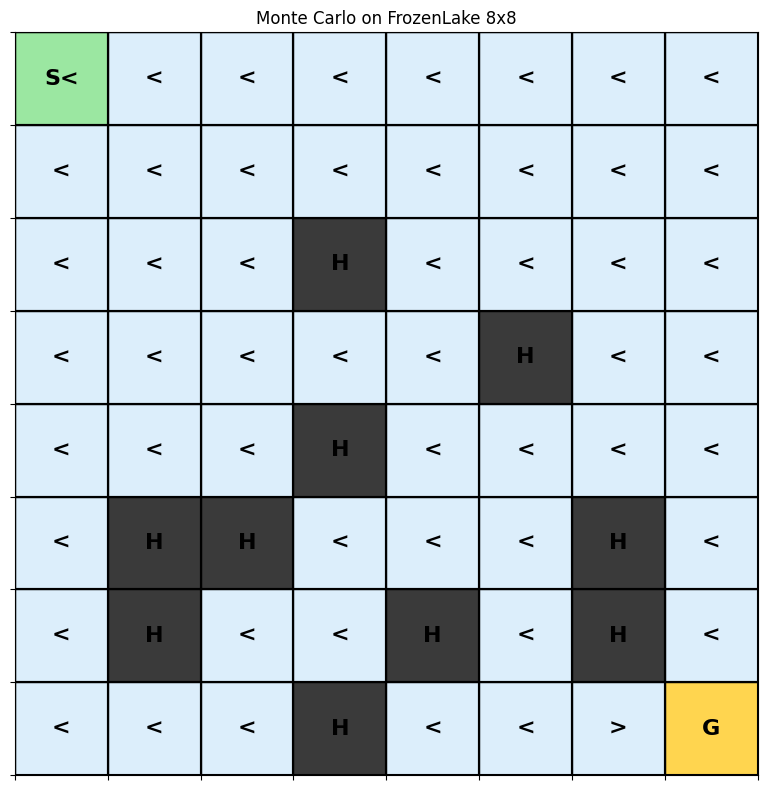

Iteration 0: Baseline Avg Reward = 0.00, Avg Length = 100.00
Iteration 1: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 2: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 3: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 4: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 5: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 6: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 7: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 8: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 9: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 10: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 11: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 12: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 13: Updated Avg Reward = 0.00, Avg Length = 100.00
Iteration 14: Updated Avg Reward = 1.00, Avg Length = 14.00
Iteration 15: Updated Avg Reward = 1.00, Avg Length = 14.00
Iteration 16: Updated Avg Reward = 

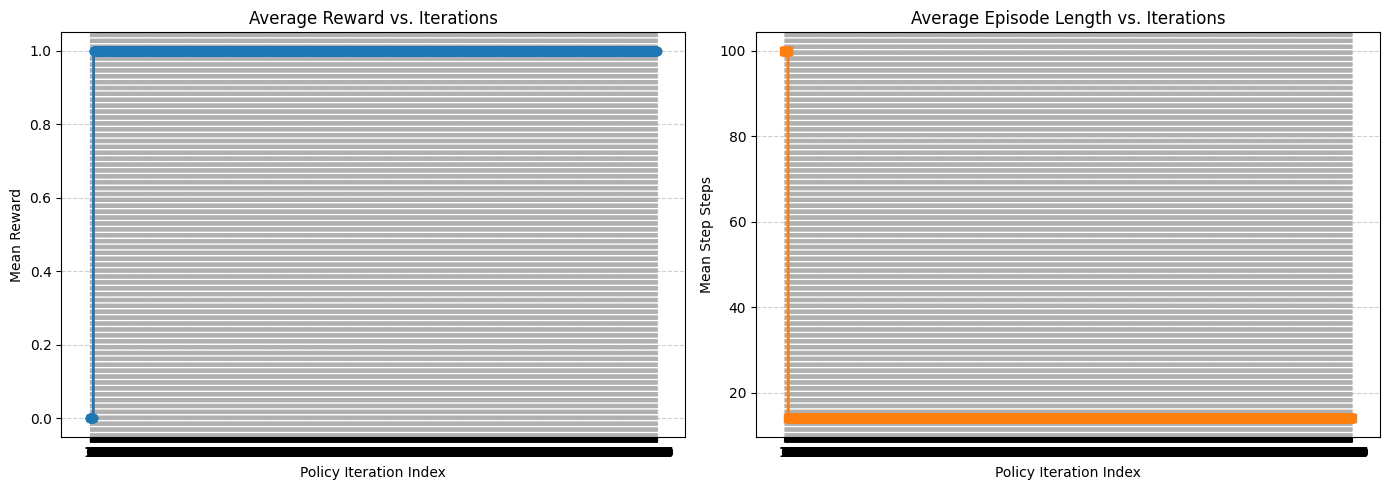

In [27]:
plot_policy_on_frozen_lake(env, optimal_policy, title="Monte Carlo on FrozenLake 8x8")
#print(optimal_policy.reshape((8, 8)))
run_and_plot_mc_policy_iteration(env)

# Documentation

## Impact of gamma

the discount factor is a parameter that determiines how much the rewards in the future are cared offor.

### gamma = 0

in this case agent only cares about the immediate next step.
unless it is standing exactly one square away from the goal, all actions look equally worthless. The policy fails to converge , resulting in random wandering and wall-bumping.

### gamma = 0.6

the agent somewhat cares about the final goal
The agent takes teh shortest possible path. because taking a longer, safer detour reduces the final value, the agent will 'skim" the holes to minimize step count.


### gamma 0.99

when gamma is near 1, the agent values a reward 50 steps from now almost as much as a reward current step.
the agent seeks the safest possible path. because the penalty for taking a longer route is negligible, the agent is willing to take a walk around the outside edge of the map to avoid walking near any holes.

## Impact of changing reward structure

### S=0; H=-1; G=1;

in this case the agent random paths but manages to reach the end goal without running into a hole.

### S=-1; H=-1; G=1;

in this case, the agent tries to run into a hole as fast as possibel. because there is penalty for staying longer but not as enough reward at goal to compensate for it

### S=-1; H=-20; G=100;

in this case, the agent takes the shortest possible path by avoiding holes to reach the goal. because there is penalty for staying longer and more penalty for falling into a hole, and enough reward at the goal to compensate